In [ ]:
!pip install transformers torch pdfplumber pytesseract pillow networkx matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 81.2 MB/s eta 0:00:00


In [ ]:
import pdfplumber
import pytesseract
from PIL import Image
from transformers import pipeline
import networkx as nx
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, pipeline,AutoModelForTokenClassification
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import io

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("dslim/bert-base-NER")
model = AutoModelForTokenClassification.from_pretrained("dslim/bert-base-NER")

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
ner_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

Device set to use cuda:0


In [ ]:
def extract_text_from_pdf(pdf_path):
    """
    Extracts text from a PDF, handling both text-based and image-based content.
    """
    text = ""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
                else:
                    im = page.to_image(resolution=300).original
                    text += pytesseract.image_to_string(im) + "\n"
    except Exception as e:
        print(f"Error extracting text from PDF: {e}")
        return None
    return text

In [ ]:
def chunk_text_with_tokenizer(text, tokenizer, max_tokens=510, stride=50):
    """
    Splits text into overlapping chunks based on tokenizer tokens to handle
    large documents.
    """
    tokens = tokenizer(
        text,
        return_overflowing_tokens=True,
        max_length=max_tokens,
        stride=stride,
        truncation=True
    )
    return [tokenizer.decode(t, skip_special_tokens=True) for t in tokens["input_ids"]]


In [ ]:
def extract_entities(text, ner_pipeline):
    """
    Extracts named entities from text using the NER pipeline.
    """
    if not text:
        return []

    chunks = chunk_text_with_tokenizer(text, ner_pipeline.tokenizer)
    all_entities = []
    for chunk in chunks:
        ents = ner_pipeline(chunk)
        all_entities.extend(ents)
    return all_entities

In [ ]:
def extract_relations_focused(entities, target_entity, window=3):
    """
    Extracts relations centered on a specific target entity within a defined window.
    """
    relations = []
    target_nodes = [ent for ent in entities if target_entity.lower() in ent['word'].lower()]

    if not target_nodes:
        return []

    entity_words = [ent['word'] for ent in entities]

    for target_node in target_nodes:
        try:
            target_index = entity_words.index(target_node['word'])
        except ValueError:
            continue

        start = max(0, target_index - window)
        end = min(len(entities), target_index + window + 1)

        for i in range(start, end):
            if i != target_index:
                e = entities[i]
                relations.append((target_node['word'], "related_to", e['word']))

    return list(set(relations))

In [ ]:
def build_knowledge_graph(entities, relations):
    """
    Builds a NetworkX graph from entities and relations.
    """
    G = nx.DiGraph()
    for ent in entities:
        G.add_node(ent['word'], label=ent['entity_group'])
    for subj, rel, obj in relations:
        G.add_edge(subj, obj, relation=rel)
    return G

In [ ]:
def plot_knowledge_graph(G, target_entity_name):
    """
    Plots the knowledge graph with improved aesthetics and error handling.

    Args:
        G (nx.DiGraph): The knowledge graph to plot.
        target_entity_name (str): The main entity to highlight.
    """
    if not G.nodes():
        print("Graph is empty. Cannot plot.")
        return None

    # Use a spring layout for better node separation
    pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)

    # Differentiate the target node
    node_colors = []
    for node in G.nodes():
        if target_entity_name.lower() in node.lower():
            node_colors.append('red')
        else:
            node_colors.append('skyblue')

    # Define node sizes based on degree centrality
    degree_centrality = nx.degree_centrality(G)
    node_sizes = [v * 5000 for v in degree_centrality.values()]

    plt.figure(figsize=(18, 12))

    # Draw nodes and edges
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=1, alpha=0.6)

    # Draw labels with adjusted font size and color
    labels = {node: node for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='black', font_weight='bold')

    # Add a title and remove the axis for a cleaner look
    plt.title(f"Knowledge Graph Centered on '{target_entity_name}'", fontsize=20)
    plt.axis('off')

    # Create a legend to explain node colors
    red_patch = plt.Line2D([0], [0], marker='o', color='w', label=target_entity_name,
                           markerfacecolor='red', markersize=15)
    blue_patch = plt.Line2D([0], [0], marker='o', color='w', label='Related Entities',
                            markerfacecolor='skyblue', markersize=15)
    plt.legend(handles=[red_patch, blue_patch], fontsize=12)

    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    plt.close()
    buf.seek(0)
    return Image.open(buf)

In [ ]:
pdf_path = "/content/Aperture Labs Report.pdf"
target_entity_name = "Linux"

In [ ]:
text = extract_text_from_pdf(pdf_path)

In [ ]:
  entities = extract_entities(text, ner_pipeline)
  relations = extract_relations_focused(entities, target_entity_name, window=5)
  G_focused = build_knowledge_graph(entities, relations)

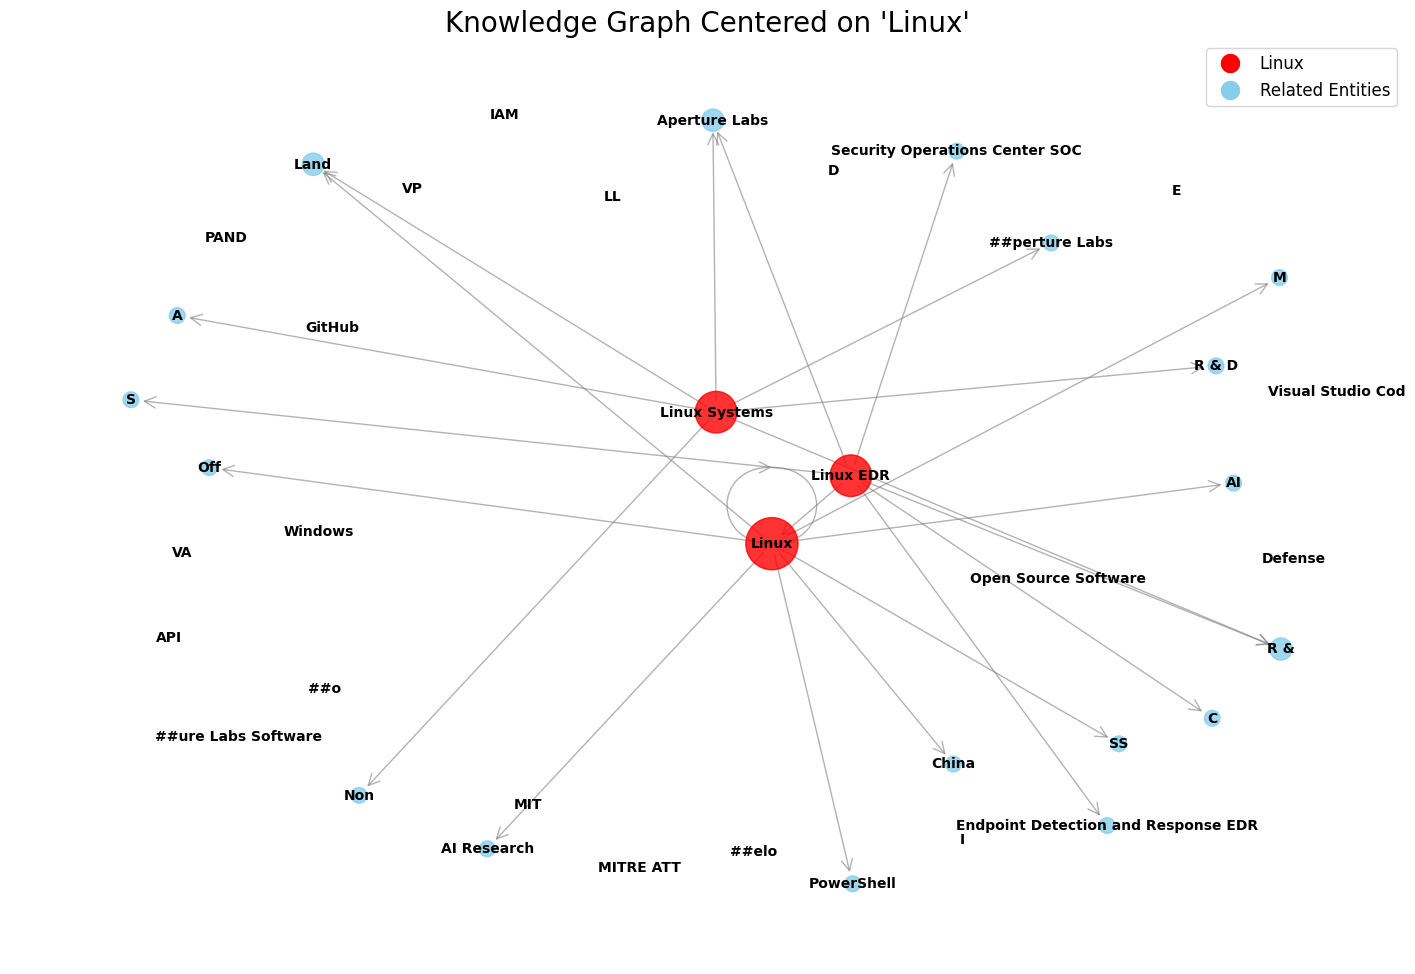

In [ ]:
plot_knowledge_graph(G_focused, target_entity_name)